The SABR (Stochastic Alpha, Beta, Rho) model is a stochastic volatility model used to capture the volatility smile observed in the market.

The model is defined by two linked stochastic differential equations:
- Forward Rate ($F$): $dF_t = \alpha_t F_t^\beta dW_t^1$
- Volatility ($\alpha$): $d\alpha_t = \nu \alpha_t dW_t^2$
- Correlation: $dW_t^1 dW_t^2 = \rho dt$

where the forward rate $F$ is related to the current stock (spot) price $S$ with risk-free rate $r$, dividend yield $q$, and time to expiry $T$ (in years) as
$$F = S \cdot e^{(r - q)T}$$

The Parameters:
- $\alpha$: The initial volatility level ($\alpha_0$) (implied by the at-the-money volatility, shifts the curve up/down).
- $\beta$: The exponent for the forward rate (0 for normal, 1 for log-normal (Black-Scholes style), 0.5 for CIR).
- $\rho$: Correlation between the rate and its volatility (controls the "skew" or slope).
- $\nu$: Volatility of volatility (controls the convexity of the "smile").

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import random
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import interp1d
from scipy.stats import norm, multivariate_normal, t as sps_t

First we extract options data for an instrument from yfinance, and also calculate historical variance standard deviation to be used for comparing with Black-Scholes (BS) model.

In [2]:
def calculate_forward_price(S, T, r, q=0.015):
    """
    S: Spot Price (from yfinance)
    T: Time to expiry (years)
    r: Risk-free rate (e.g., 0.04 for 4%)
    q: Dividend yield (e.g., 0.015 for 1.5% for SPY)
    """
    return S * np.exp((r - q) * T)

def get_live_sabr_data(ticker_symbol, expiration_index=1):
    ticker = yf.Ticker(ticker_symbol)

    # Get current price (Forward price F approximation)
    S = ticker.fast_info['lastPrice']

    # Get available expiration dates and pick one (default is the second available)
    expiries = ticker.options
    target_expiry = expiries[expiration_index]

    # Calculate Time to Maturity (T) in years
    days_to_expiry = (pd.to_datetime(target_expiry) - pd.Timestamp.now()).days
    T = max(days_to_expiry / 365.0, 1/365.0)

    # Get the option chain
    opt = ticker.option_chain(target_expiry)
    calls = opt.calls

    # Clean data: Filter for liquidity (openInterest > 0) and remove zero IVs
    df = calls[(calls['openInterest'] > 10) & (calls['impliedVolatility'] > 0.01)].copy()

    # We only need strikes and market implied volatilities
    market_strikes = df['strike'].values
    market_vols = df['impliedVolatility'].values

    return S, T, market_strikes, market_vols, target_expiry

# Example: Get data for a stock
ticker_symbol = "SPY" # Try GC=F (for gold)
expiration_index=15

ticker = yf.Ticker(ticker_symbol)
S, T, strikes, vols, date = get_live_sabr_data(ticker_symbol, expiration_index) # Use expiration date at least 1.5 months later (i.e., expiration index at least 10 for SPY) for decent data
r = 0.045
q = 0.015
F = calculate_forward_price(S, T, r, q)

# Calculate Historical Volatility (Constant Vol Baseline)
hist_data = ticker.history(period="1y")
# log_returns = np.log(hist_data['Close'] / hist_data['Close'].shift(1)) # One can use log returns instead of simple returns due to their additive properties
# const_vol_baseline = log_returns.std() * np.sqrt(252)
returns = hist_data['Close'].pct_change() # One can use 'Adj Close' instead of 'Close' to account for dividends and stock splits whenever possible
const_vol_baseline = returns.std() * np.sqrt(252) # To make the data annualized from daily

opt_chain = ticker.option_chain(date).calls

# Filter for liquid strikes near the money (within 10%)
mask = (opt_chain['strike'] > F * 0.9) & (opt_chain['strike'] < F * 1.1) & (opt_chain['openInterest'] > 100)
market_data = opt_chain[mask]
available_strikes = market_data['strike'].values

print(f"Data for {date}: F={F:.2f}, T={T:.3f} years, {len(strikes)} strikes found.")

Data for 2026-07-31: F=743.68, T=0.203 years, 175 strikes found.


At the industry level, the forward price is also calulated using the Put-Call Parity. The strike price at which put and call options have same price is the forward price.

In [3]:
def get_implied_forward(ticker_symbol, expiration_index):
    ticker = yf.Ticker(ticker_symbol)

    # Get the specific expiry date
    expiry = ticker.options[expiration_index]
    opt = ticker.option_chain(expiry)

    calls = opt.calls[['strike', 'lastPrice']].rename(columns={'lastPrice': 'call_price'})
    puts = opt.puts[['strike', 'lastPrice']].rename(columns={'lastPrice': 'put_price'})

    # Merge calls and puts on strike price
    df = pd.merge(calls, puts, on='strike').dropna()

    # Calculate the price difference
    df['diff'] = df['call_price'] - df['put_price'] # We want to find where diff = 0.

    # Since we have discrete strikes, we use interpolation.
    if (df['diff'] > 0).any() and (df['diff'] < 0).any():

        # Create an interpolation function: Strike as a function of Price Difference
        df = df.sort_values('diff') # Sort values to ensure a clean interpolation
        f_interp = interp1d(df['diff'], df['strike'], kind='linear', fill_value="extrapolate")

        implied_f = float(f_interp(0))
        return implied_f, expiry
    else:
        # Fallback to the strike with the minimum absolute difference
        idx = df['diff'].abs().idxmin()
        return df.loc[idx, 'strike'], expiry

# --- Execution ---
f_implied, date = get_implied_forward(ticker_symbol, expiration_index)

print(f"Ticker: {ticker_symbol}")
print(f"Expiry Date: {date}")
print(f"Forward Price from Put-Call Parity: {f_implied:.2f}")
print(f"Forward Price from Spot price: {F:.2f}")
F = f_implied

Ticker: SPY
Expiry Date: 2026-07-31
Forward Price from Put-Call Parity: 744.63
Forward Price from Spot price: 743.68


Since the forward price is similar in both cases, we will use the one coming from the Put-Call Parity.

Using singular perturbation, we get the closed-form approximation for $\sigma_\text{Black}$.

$\sigma_\text{Black}(F,K) = \frac{\alpha}{(FK)^{\frac{1-\beta}{2}} \left\{ 1 + \frac{(1-\beta)^2}{24} \ln^2 \frac{F}{K} + \frac{(1-\beta)^4}{1920}\ln^4 \frac{F}{K} + \cdots \right\}} \cdot \frac{z}{x(z)} \cdot \{ 1 + \left[ \frac{(1-\beta)^2}{24} \frac{\alpha^2}{(FK)^{1-\beta}} + \frac{1}{4}\frac{\alpha \beta \rho \nu}{(FK)^{\frac{1-\beta}{2}}} + \frac{2-3\rho^2}{24}\nu^2\right] T + \cdots$

Here,

$z = \frac{\nu}{\alpha} (FK)^{\frac{1-\beta}{2}} \ln \frac{F}{K}$,

$x(z) = \ln \frac{\sqrt{1 - 2\rho z + z^2} + z - \rho}{1 - \rho}$,

$T$ is the time to expiry.

Note that the formula of $\sigma_\text{Black}$ is slightly different for Normal (Bachelier) Volatility version which is usually used for modelling interest rates, as they can go negative. The formula given above uses the Log-normal (Black) Volatility version, which is the industry standard for Equities, FX (like USDINR), and Commodities.

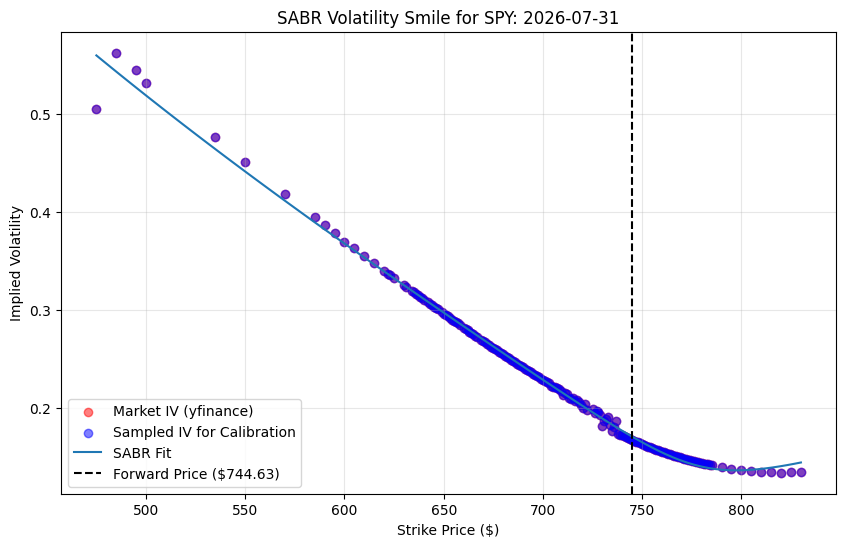

Parameters: alpha = 123.24, beta = 0.00, rho = -0.64, nu = 2.37, sample error: 0.005258, population error: 0.005258


In [4]:
def sabr_vol(F, K, T, alpha, beta, rho, nu):
    V = (F * K) ** ((1 - beta) / 2)
    log_FK = np.log(F / K)

    z = (nu / alpha) * V * log_FK

    # x(z) function
    x_z = np.log((np.sqrt(1 - 2 * rho * z + z**2) + z - rho) / (1 - rho))

    # Core Hagan approximation components
    A = alpha / (V * (1 + ((1 - beta)**2 / 24) * log_FK**2 + ((1 - beta)**4 / 1920) * log_FK**4))
    B = 1 + (((1 - beta)**2 / 24) * (alpha**2 / V**2) +
             (1/4) * (alpha * beta * rho * nu  / V) +
             ((2 - 3 * rho**2) / 24) * nu**2) * T

    if F == K:
        return A * B
    else:
        return A * (z / x_z) * B

def calibrate_sabr(market_vols, strikes, F, T):
    # objective function: minimize Sum of Squared Errors (SSE)
    def objective(params):
        alpha, beta, rho, nu = params
        # Constraints: alpha > 0, nu > 0, -1 < rho < 1
        if alpha <= 0 or nu <= 0 or abs(rho) >= 1:
            return 1e10

        model_vols = [sabr_vol(F, K, T, alpha, beta, rho, nu) for K in strikes]
        return np.sum((np.array(market_vols) - np.array(model_vols))**2)

    initial_guess = [0.01, 0.5, -0.5, 0.1] # might need to change the initial guess if we get horizontal line as the fit
    result = minimize(objective, initial_guess, method='L-BFGS-B', bounds=[(1e-6, 1e10), (0, 1), (-1, 1), (1e-6, 1e10)]) # Try Nelder-Mead if we get a flat line
    return result

# Generate a sample of market data for calibration in case of outliers or huge data size
# Combine strikes and vols, then sample
combined_data = list(zip(strikes, vols))
num_calibration_samples = min(len(combined_data), 1e10) # Ensure we don't sample more than available
sampled_data = random.sample(combined_data, num_calibration_samples)
sampled_strikes = np.array([d[0] for d in sampled_data])
sampled_vols = np.array([d[1] for d in sampled_data])

# Calibrate with sampled data
calibration_result = calibrate_sabr(sampled_vols, sampled_strikes, F, T)
params = calibration_result.x
sampled_error = calibration_result.fun
alpha_cal, beta_cal, rho_cal, nu_cal = params

# Calculate error for the entire population using calibrated parameters
full_market_model_vols = [sabr_vol(F, K, T, alpha_cal, beta_cal, rho_cal, nu_cal) for K in strikes]
full_market_error = np.sum((np.array(vols) - np.array(full_market_model_vols))**2)

# Generate the fitted smile (using the full range of strikes for visualization)
plot_strikes = np.linspace(min(strikes), max(strikes), 100)
sabr_fitted_vols = [sabr_vol(F, K, T, alpha_cal, beta_cal, rho_cal, nu_cal) for K in plot_strikes]

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(strikes, vols, color='red', alpha=0.5, label='Market IV (yfinance)')
plt.scatter(sampled_strikes, sampled_vols, color='blue', alpha=0.5, label='Sampled IV for Calibration')
plt.plot(plot_strikes, sabr_fitted_vols, label=f'SABR Fit')
plt.axvline(F, color='black', linestyle='--', label=f'Forward Price (${F:.2f})')
plt.title(f"SABR Volatility Smile for {ticker_symbol}: {date}")
plt.xlabel("Strike Price ($)")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f'Parameters: alpha = {alpha_cal:.2f}, beta = {beta_cal:.2f}, rho = {rho_cal:.2f}, nu = {nu_cal:.2f}, sample error: {sampled_error:.6f}, population error: {full_market_error:.6f}')

- $\alpha$ is the ATM volatility.
- $\rho$ is negative as expected.
- Positive value of $\nu$ shows that volatility itself is volatile and not constant like Black-Scholes assumption.

- For equities and commodities (like GLD), we have mirror image since, the dropping price creates more fear and hence volatility in case of equities, as opposed to commodities.
- On the other hand, FX Swaptions give a symmetric volatility smile. (Difficult to fetch FX swaptions data from yfinance as they are usually traded Over-the-Counter (OTC) or at specific exchanges that do not give access to yfinance).

Now we compare option prices for certain options using SABR model and Black-Scholes model (that uses a constant volatility—a historical average).  

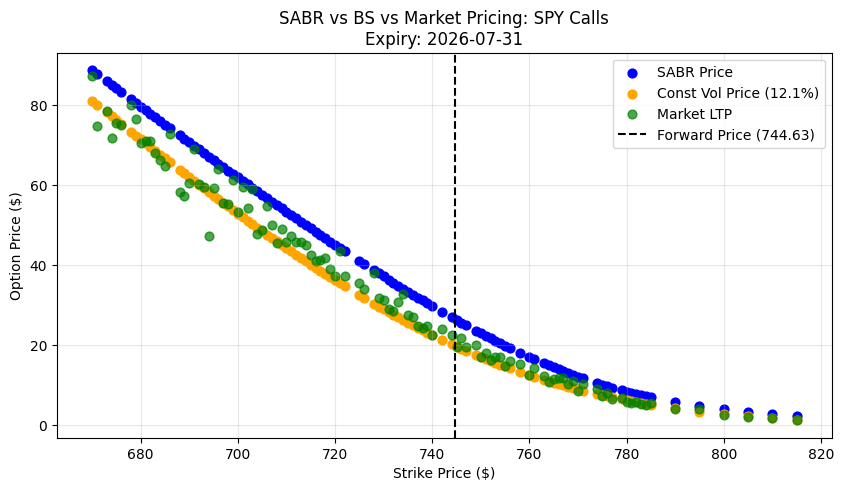

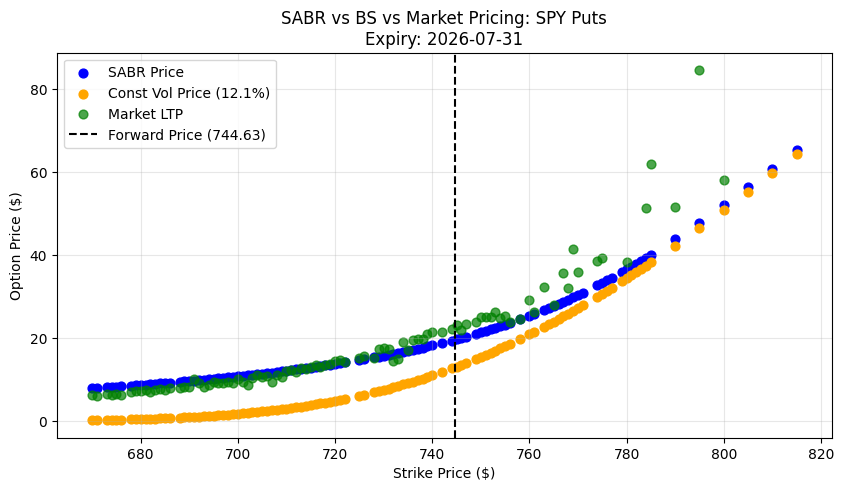

In [5]:
# Closed form formula for BS option pricing
def black_scholes_price(S, K, T, r, sigma, option_type='call'):
    if T <= 0 or sigma <= 0: return max(0, S - K) if option_type == 'call' else max(0, K - S)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type.lower() == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Calculating call option prices
sabr_call_prices = []
const_vol_call_prices = []

# Fetch market call data for comparison
market_calls = ticker.option_chain(date).calls
market_calls_filtered = market_calls[market_calls['strike'].isin(available_strikes)]
# Ensure the market prices are aligned with the available_strikes order
market_calls_prices = market_calls_filtered.set_index('strike').reindex(available_strikes)['lastPrice'].values

for K in available_strikes:
    vol_s = sabr_vol(F, K, T, alpha_cal, beta_cal, rho_cal, nu_cal)
    sabr_call_prices.append(black_scholes_price(F, K, T, r, vol_s, 'call'))
    const_vol_call_prices.append(black_scholes_price(F, K, T, r, const_vol_baseline, 'call'))

sabr_call_prices = np.array(sabr_call_prices)
const_vol_call_prices = np.array(const_vol_call_prices)

# Visualization
plt.figure(figsize=(10, 5))
plt.scatter(available_strikes, sabr_call_prices, color='blue', label='SABR Price', s=40)
plt.scatter(available_strikes, const_vol_call_prices, color='orange', label=f'Const Vol Price ({const_vol_baseline:.1%})', s=40)
plt.scatter(available_strikes, market_calls_prices, color='green', label='Market LTP', marker='o', s=40, alpha=0.7)
plt.axvline(F, color='black', linestyle='--', label=f'Forward Price ({F:.2f})')
plt.title(f"SABR vs BS vs Market Pricing: {ticker_symbol} Calls\nExpiry: {date}")
plt.xlabel("Strike Price ($)")
plt.ylabel("Option Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print('\n')
# Calculating put option prices
sabr_put_prices = []
const_vol_put_prices = []

# Fetch market put data for comparison
market_puts = ticker.option_chain(date).puts
market_puts_filtered = market_puts[market_puts['strike'].isin(available_strikes)]
market_puts_prices = market_puts_filtered.set_index('strike').reindex(available_strikes)['lastPrice'].values

for K in available_strikes:
    vol_s = sabr_vol(F, K, T, alpha_cal, beta_cal, rho_cal, nu_cal)
    sabr_put_prices.append(black_scholes_price(F, K, T, r, vol_s, 'put'))
    const_vol_put_prices.append(black_scholes_price(F, K, T, r, const_vol_baseline, 'put'))

sabr_put_prices = np.array(sabr_put_prices)
const_vol_put_prices = np.array(const_vol_put_prices)

# Visualization
plt.figure(figsize=(10, 5))
plt.scatter(available_strikes, sabr_put_prices, color='blue', label='SABR Price', s=40)
plt.scatter(available_strikes, const_vol_put_prices, color='orange', label=f'Const Vol Price ({const_vol_baseline:.1%})', s=40)
plt.scatter(available_strikes, market_puts_prices, color='green', label='Market LTP', marker='o', s=40, alpha=0.7)
plt.axvline(F, color='black', linestyle='--', label=f'Forward Price ({F:.2f})')
plt.title(f"SABR vs BS vs Market Pricing: {ticker_symbol} Puts\nExpiry: {date}")
plt.xlabel("Strike Price ($)")
plt.ylabel("Option Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

We are seeing that OTM strikes have higher BS price than the SABR price, this is because the historical volatility is higher than usual and SABR model expects it to calm down in the future.

Had it been the opposite case, the rationale behind it would have been that $\nu$ in the SABR model considers excess kurtosis, and hence, it gives higher probability to extreme events (i.e., considers fatter tails) compared to the normalality assumption of the BS model.

Now we calculate the Greeks for the SABR model.
- $\Delta = \frac{\partial V}{\partial F}$ (The amount of stock one needs to buy to hedge against a sold call).
- $\Gamma = \frac{\partial^2 V}{\partial F^2}$ (How frequently one needs to update their hedging amount of stock as the stock price changes).
- $\mathcal{V} = \frac{\partial V}{\partial \alpha}$ (How does option price changes with change in the volatility).
- $\text{Vanna} = \frac{\partial^2 V}{\partial F \partial \alpha}$ (How does $\mathcal{V}$ changes with change in the stock price).
- $\text{Volga} = \frac{\partial^2 V}{\partial \alpha^2} $. (How does $\mathcal{V}$ changes with change in the volatility). This is also called Vomma in the BS context.

Vanna is related to $\rho$ and Volga is related to $\nu$.

In their original 2002 paper, Managing Smile Risk, Hagan et al. provided a bridge between the SABR model and the Black-Scholes world. They gave a way to calulate SABR Greeks analytically using BS Greeks. However, we don't cover that aspect in this study.

In [6]:
def sabr_greeks(F, K, T, r, alpha, beta, rho, nu, option_type='call'):
    """
    Calculates Delta, Gamma, Vega, Vanna, and Volga using numerical bumping.
    """
    # Helper: Get price from SABR parameters
    def get_price(f_val, alpha_val):
        vol = sabr_vol(f_val, K, T, alpha_val, beta, rho, nu)
        return black_scholes_price(f_val, K, T, r-q, vol, option_type)

    # Define bump sizes
    df = F * 0.0001      # 0.01% bump for Delta/Gamma
    da = alpha * 0.0001  # 0.01% bump for Vega/Vanna/Volga

    # Delta & Gamma (Rate risk)
    p0 = get_price(F, alpha)
    p_up = get_price(F + df, alpha)
    p_dn = get_price(F - df, alpha)

    delta = (p_up - p_dn) / (2 * df)
    gamma = (p_up - 2 * p0 + p_dn) / (df ** 2)

    # Vega (Volatility scale risk)
    p_a_up = get_price(F, alpha + da)
    p_a_dn = get_price(F, alpha - da)

    vega = (p_a_up - p_a_dn) / (2 * da)

    # Vanna (Sensitivity of Delta to Alpha / Sensitivity of Vega to Rate)
    p_f_up_a_up = get_price(F + df, alpha + da)
    p_f_up_a_dn = get_price(F + df, alpha - da)
    p_f_dn_a_up = get_price(F - df, alpha + da)
    p_f_dn_a_dn = get_price(F - df, alpha - da)

    vanna = (p_f_up_a_up - p_f_up_a_dn - p_f_dn_a_up + p_f_dn_a_dn) / (4 * df * da)

    # Volga (Vomma - Sensitivity of Vega to Alpha)
    volga = (p_a_up - 2 * p0 + p_a_dn) / (da ** 2)

    return {
        "Delta": delta,
        "Gamma": gamma,
        "Vega": vega,
        "Vanna": vanna,
        "Volga": volga
    }

# Testing the example
K_test = F

greeks = sabr_greeks(F, K_test, T, r-q, alpha_cal, beta_cal, rho_cal, nu_cal)

for greek, value in greeks.items():
    print(f"{greek}: {value:.6f}")

Delta: 0.656651
Gamma: 0.007831
Vega: 0.185726
Vanna: -0.000127
Volga: 0.000002


Now we calculate the Greeks using BS model. We use the following well-known closed form formulas (instead of method of bumping) to calculate the Greeks.

Conventions:
- $\phi$: pdf of the normal distribution
- $\Phi$: cdf of the normal distribution
- $d_1 = \frac{\ln \left(\frac{S}{K}\right) + \left(r-q + \frac{1}{2} \sigma^2\right) T}{\sigma \sqrt{T}}$
- $d_2 = d_1 - \sigma\sqrt{T}$

Then the Greeks are:
- $\Delta = \Phi (d_1)$
- $\Gamma = \frac{\phi(d1)}{S \sigma \sqrt{T}}$
- $\mathcal{V} = S \phi(d1) \sqrt{T}$
- $\text{Vanna} = \frac{\mathcal{V} (1 - d_1)}{S\sigma \sqrt{T}}$
- $\text{Vomma} = \frac{\mathcal{V} d_1 d_2}{\sigma}$

In [7]:
def bs_greeks(F, K, T, r, sigma, q = 0.015, option_type='call'):
    """
    Calculates Greeks using Black-Scholes formula.
    """
    S = F * np.exp((- r + q) * T)
    # Basic Black-Scholes Greeks (The "Direct" components)
    d1 = (np.log(S / K) + (r-q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Black-Scholes Delta
    if option_type == 'call':
        delta_bs = norm.cdf(d1)
    else:
        delta_bs = norm.cdf(d1) - 1

    # Black-Scholes Gamma
    gamma_bs = norm.pdf(d1) / (S * sigma * np.sqrt(T))

    # Black-Scholes Vega
    vega_bs = S * norm.pdf(d1) * np.sqrt(T)

    # Black-Scholes Vanna
    vanna_bs = (vega_bs / S) * (1 - d1 / (sigma * np.sqrt(T)))

    # Black-Scholes Vomma (Volga)
    vomma_bs = vega_bs * (d1 * d2 / sigma)

    return {
        "Delta": delta_bs,
        "Gamma": gamma_bs,
        "Vega": vega_bs,
        "Vanna": vanna_bs,
        "Volga (Vomma)": vomma_bs
    }

# Testing the example

K_test = F

greeks = bs_greeks(F, K_test, T, r-q, const_vol_baseline)

for greek, value in greeks.items():
    print(f"{greek}: {value:.6f}")

Delta: 0.510889
Gamma: 0.009839
Vega: 133.302992
Vanna: 0.089782
Volga (Vomma): -0.819238


Usually, SABR Greeks are calculated using derivatives with respect to the forward price, instead of the spot price (like Black-Scholes model). One can get the spot values using the forward values, with the help of chain rule as follows.

- $\Delta_{\text{Spot}} = \Delta_{\text{Forward}} \times e^{(r-q)T} $
- $\Gamma_{\text{Spot}} = \Gamma_{\text{Forward}} \times e^{2(r-q)T} $
- $\text{Vanna}_{\text{Spot}} = \text{Vanna}_{\text{Forward}} \times e^{(r-q)T} $

In [8]:
rows = []
for K in available_strikes:
    s_metrics = sabr_greeks(F, K, T, r-q, alpha_cal, beta_cal, rho_cal, nu_cal)
    b_metrics = bs_greeks(F, K, T, r-q, const_vol_baseline)
    vol_s = sabr_vol(F, K, T, alpha_cal, beta_cal, rho_cal, nu_cal) # Calculate vol_s inside the loop

    rows.append({
        "Strike": round(K, 2),
        "SABR_IV": round(vol_s, 4),
        "SABR_Delta": round(s_metrics['Delta'], 4),
        "Spot_SABR_Delta": round(s_metrics['Delta'] * np.exp((r - q)*T), 4),
        "BS_Delta": round(b_metrics['Delta'], 4),
        "SABR_Gamma": round(s_metrics['Gamma'], 6),
        "Spot_SABR_Gamma": round(s_metrics['Gamma'] * np.exp(2*(r - q)*T), 6),
        "BS_Gamma": round(b_metrics['Gamma'], 6),
        "Spot_SABR_Vega": round(s_metrics['Vega'], 4),
        "BS_Vega": round(b_metrics['Vega'], 4),
        "SABR_Vanna": round(s_metrics['Vanna'], 6),
        "Spot_SABR_Vanna": round(s_metrics['Vanna'] * np.exp((r - q)*T), 4),
        "BS_Vanna": round(b_metrics['Vanna'], 6),
        "Spot_SABR_Volga": round(s_metrics['Volga'], 6),
        "BS_Volga": round(b_metrics['Volga (Vomma)'], 6)
    })

df_comparison = pd.DataFrame(rows)

# Display
print(f"--- {ticker_symbol} SABR vs Black-Scholes Greeks Comparison ---")
print(f"Forward: {F:.2f} | Hist Vol: {const_vol_baseline:.2%} | Expiry date: {date}")
print(df_comparison.head(10).to_string(index=False))

--- SPY SABR vs Black-Scholes Greeks Comparison ---
Forward: 744.63 | Hist Vol: 12.13% | Expiry date: 2026-07-31
 Strike  SABR_IV  SABR_Delta  Spot_SABR_Delta  BS_Delta  SABR_Gamma  Spot_SABR_Gamma  BS_Gamma  Spot_SABR_Vega  BS_Vega  SABR_Vanna  Spot_SABR_Vanna  BS_Vanna  Spot_SABR_Volga   BS_Volga
  670.0   0.2699      0.9141           0.9197    0.9751    0.001265         0.001281  0.001437          0.1255  19.4665   -0.000803          -0.0008 -0.916007         0.000506 600.678562
  671.0   0.2686      0.9128           0.9184    0.9735    0.001291         0.001307  0.001515          0.1263  20.5305   -0.000809          -0.0008 -0.952238         0.000503 615.742102
  673.0   0.2658      0.9102           0.9158    0.9699    0.001345         0.001361  0.001681          0.1279  22.7800   -0.000820          -0.0008 -1.025931         0.000496 644.699648
  674.0   0.2645      0.9089           0.9144    0.9680    0.001373         0.001389  0.001769          0.1287  23.9661   -0.000826        

Now we visualize the relevant components of the dataframe below.

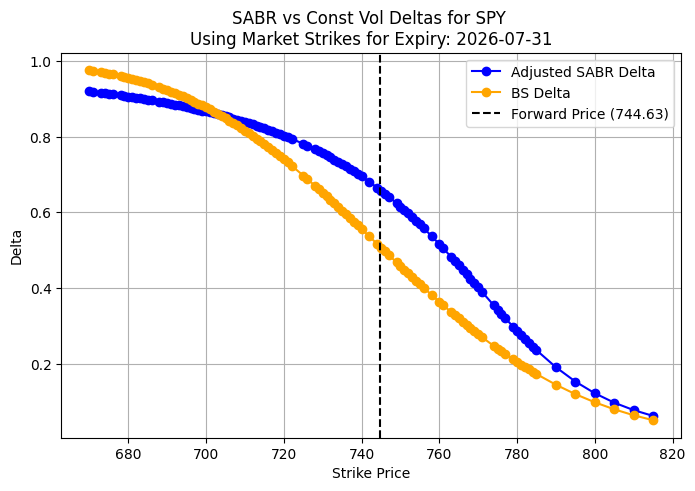

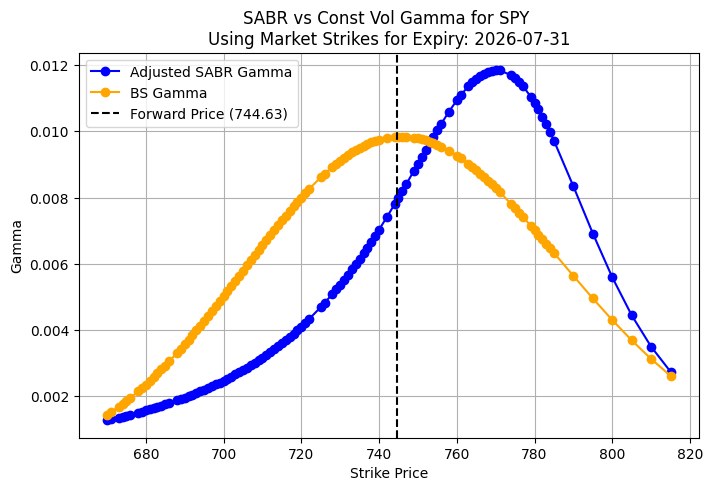

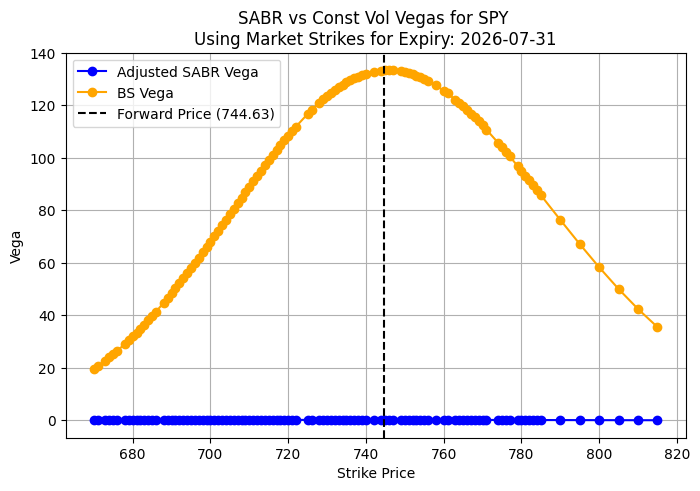

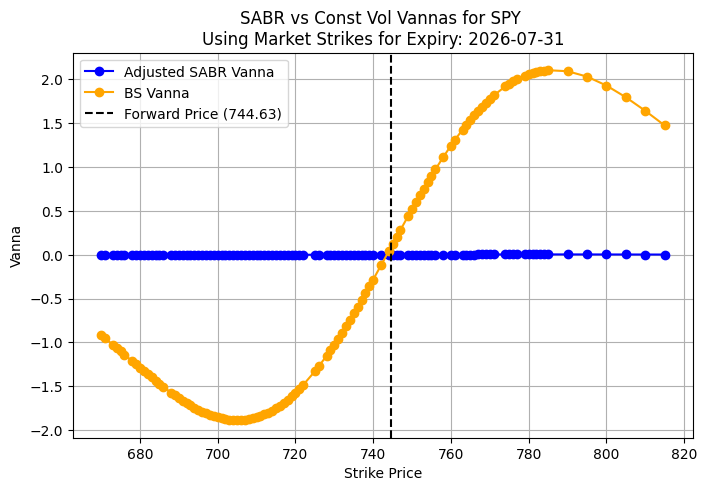

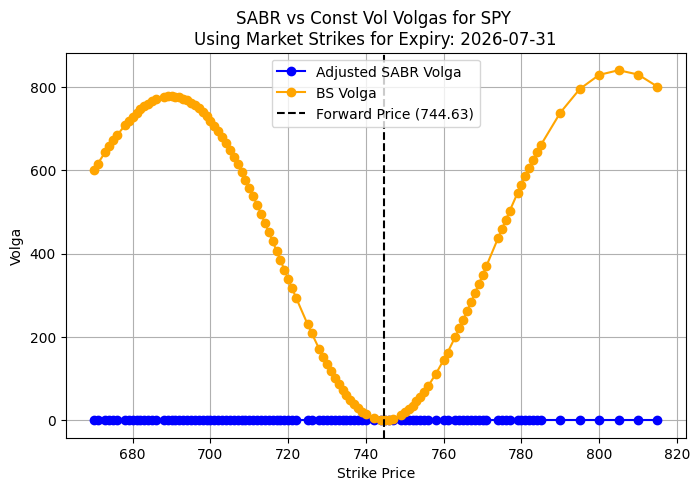

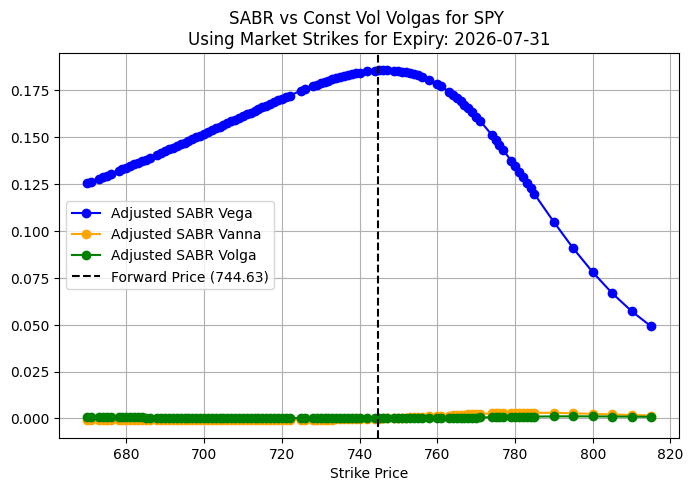

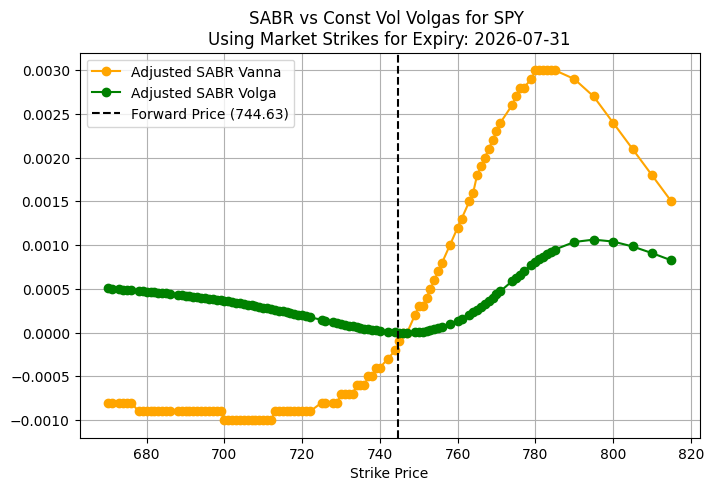

In [9]:
greeks = {
    'Delta': 'Deltas',
    'Gamma': 'Gamma',
    'Vega': 'Vegas',
    'Vanna': 'Vannas',
    'Volga': 'Volgas'
}

for greek, title_suffix in greeks.items():
    plt.figure(figsize=(8, 5))

    # Plot SABR and Black-Scholes data
    plt.plot(df_comparison['Strike'], df_comparison[f'Spot_SABR_{greek}'],
             label=f'Adjusted SABR {greek}', color='blue', marker='o')
    plt.plot(df_comparison['Strike'], df_comparison[f'BS_{greek}'],
             label=f'BS {greek}', color='orange', marker='o')
    plt.axvline(F, color='black', linestyle='--', label=f'Forward Price ({F:.2f})')
    plt.xlabel('Strike Price')
    plt.ylabel(greek)
    plt.legend()
    plt.title(f"SABR vs Const Vol {title_suffix} for {ticker_symbol} \n"
              f"Using Market Strikes for Expiry: {date}")
    plt.grid(True)

    plt.show()
    print('\n')

plt.figure(figsize=(8, 5))

# Plot SABR and Black-Scholes data
plt.plot(df_comparison['Strike'], df_comparison['Spot_SABR_Vega'],
          label='Adjusted SABR Vega', color='blue', marker='o')
plt.plot(df_comparison['Strike'], df_comparison['Spot_SABR_Vanna'],
          label='Adjusted SABR Vanna', color='orange', marker='o')
plt.plot(df_comparison['Strike'], df_comparison['Spot_SABR_Volga'],
          label='Adjusted SABR Volga', color='green', marker='o')
plt.axvline(F, color='black', linestyle='--', label=f'Forward Price ({F:.2f})')
plt.xlabel('Strike Price')
plt.legend()
plt.title(f"SABR vs Const Vol {title_suffix} for {ticker_symbol} \n"
          f"Using Market Strikes for Expiry: {date}")
plt.grid(True)
plt.show()
print('\n')

plt.figure(figsize=(8, 5))

# Plot SABR and Black-Scholes data
plt.plot(df_comparison['Strike'], df_comparison['Spot_SABR_Vanna'],
          label='Adjusted SABR Vanna', color='orange', marker='o')
plt.plot(df_comparison['Strike'], df_comparison['Spot_SABR_Volga'],
          label='Adjusted SABR Volga', color='green', marker='o')
plt.axvline(F, color='black', linestyle='--', label=f'Forward Price ({F:.2f})')
plt.xlabel('Strike Price')
plt.legend()
plt.title(f"SABR vs Const Vol {title_suffix} for {ticker_symbol} \n"
          f"Using Market Strikes for Expiry: {date}")
plt.grid(True)

plt.show()

Delta hedging (using underlying stock)
-
Now we use the deltas to hedge against a sold call and backtest this hedging strategy. Delta measures the sensitivity of the option price to changes in the underlying asset price. A delta-neutral portfolio aims to have its value unchanged by small movements in the underlying asset. To hedge the Delta of a short option position, one buys or sells a certain amount of the underlying stock.


In [10]:
# Initialization
t = 1
n_steps = 252
dt = t/n_steps
deltas = np.zeros(n_steps)
times = np.linspace(0,t, n_steps + 1)

# Data extraction
stock_data = yf.download(ticker_symbol, period = '2y', interval = '1d')
stock_path = np.array(stock_data['Close'][ticker_symbol].values[-n_steps-1:])
K = stock_path[0] # ATM Call just to begin with

# Generating deltas
for i in range(n_steps):
    s_metrics = sabr_greeks(stock_path[i]*np.exp((r - q)*((t-times)[i])), K, (t-times)[i], r, alpha_cal, beta_cal, rho_cal, nu_cal)
    deltas[i] = s_metrics['Delta'] * np.exp((r - q)*((t-times)[i]))

# Calculating the outcomes
stock_profits = (stock_path[1:n_steps+1] - stock_path[0:n_steps]*np.exp((r-q)*dt))*np.exp((q-r)*times[1:n_steps+1])*deltas
total_stock_profit = np.sum(stock_profits)
call_payout = np.maximum(stock_path[-1] - K, 0)*np.exp((q-r)*t)
call_profit_hedged = call_payout + total_stock_profit

# Display
print(f"Call payout: ${call_payout:.2f} \nStock profit: ${total_stock_profit:.2f}\nTotal profit of the hedging strategy: ${call_profit_hedged:.2f}.")

/tmp/ipykernel_40333/819605836.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker_symbol, period = '2y', interval = '1d')
[*********************100%***********************]  1 of 1 completed


Call payout: $153.56 
Stock profit: $132.29
Total profit of the hedging strategy: $285.85.


# Other Greeks Hedging (using another Option)
Gamma Hedging
-
Gamma measures the rate of change of Delta with respect to changes in the underlying asset price. A portfolio with high absolute Gamma will experience large changes in Delta as the underlying moves, requiring frequent re-hedging (dynamic delta hedging). Gamma hedging aims to make the portfolio's. Gamma close to zero, thereby stabilizing Delta and reducing the frequency of re-hedging. To hedge the Gamma of a short option position, one typically buys options (long gamma). To make a portfolio Gamma-neutral, we need to add a position in a hedging instrument whose Gamma offsets the portfolio's Gamma.

In [11]:
# --- Hedging Strategies Using Other Greeks ---# Assume we are short 1 unit of a call option at the money (K = F)
# We will use the underlying stock for Delta hedging, and another call option with a different strike (K_hedge) as our instrument for hedging other Greeks (Gamma, Vega, Vanna, Volga).

K_main = F # At-the-money call
K_hedge = F + 0.1 * F # Define the strike for our hypothetical hedging option (for Gamma, Vega, Vanna, Volga)

print(f"Hedging a short call option (Strike: ${K_main:.2f})\n")
print(f"  - Delta Hedging Instrument: Underlying Stock (Current price: ${F:.2f})")
print(f"  - Other Greeks Hedging Instrument: Another Call Option (Strike: ${K_hedge:.2f})\n")


# Calculate Greeks for the main option (short 1 unit)
greeks_main_option = sabr_greeks(F, K_main, T, r-q, alpha_cal, beta_cal, rho_cal, nu_cal, option_type='call')

# Calculate Greeks for the hedging option (to be bought/sold)
greeks_hedge_option = sabr_greeks(F, K_hedge, T, r-q, alpha_cal, beta_cal, rho_cal, nu_cal, option_type='call')

print("--- Greeks of Main Option (Short 1 unit) ---")
for greek, value in greeks_main_option.items():
    print(f"{greek}: {value:.6f}")
print("\n--- Greeks of Hedging Option (for Gamma, Vega, Vanna, Volga) ---")
for greek, value in greeks_hedge_option.items():
    print(f"{greek}: {value:.6f}")
print("\n")
portfolio_delta = -1 * greeks_main_option['Delta'] # Short 1 main option
hedge_stock_delta = 1.0

num_hedge_stock_units = -portfolio_delta / hedge_stock_delta
if num_hedge_stock_units >= 0:
    delta_action = "buy"
else:
    delta_action = "sell"
print(f"To achieve Delta neutrality, you would need to {delta_action} {np.abs(num_hedge_stock_units):.2f} units of the underlying stock.")
print(f"Initial Portfolio Delta: {portfolio_delta:.6f}")
print(f"Underlying Stock Delta: {hedge_stock_delta:.6f}")
print(f"Portfolio Delta after hedging: {portfolio_delta + num_hedge_stock_units * hedge_stock_delta:.6f}\n")

# --- Gamma Hedging (using another Option) ---

portfolio_gamma = -1 * greeks_main_option['Gamma'] # Short 1 main option
hedge_gamma = greeks_hedge_option['Gamma']

if hedge_gamma != 0:
    num_hedge_gamma_units = -portfolio_gamma / hedge_gamma
    if num_hedge_gamma_units >= 0:
        gamma_action = "buy"
    else:
        gamma_action = "sell"
    print(f"To achieve Gamma neutrality, you would need to {gamma_action} {np.abs(num_hedge_gamma_units):.2f} units of the hedging option.")
else:
    print("Cannot perform Gamma hedging with the chosen hedging instrument (Gamma is zero or very small).")

print(f"Initial Portfolio Gamma: {portfolio_gamma:.6f}")
print(f"Hedging Option Gamma: {hedge_gamma:.6f}")
print(f"Portfolio Gamma after hedging: {portfolio_gamma + num_hedge_gamma_units * hedge_gamma if hedge_gamma != 0 else portfolio_gamma:.6f}\n")

# --- Vega Hedging (using another Option) ---

portfolio_vega = -1 * greeks_main_option['Vega'] # Short 1 main option
hedge_vega = greeks_hedge_option['Vega']

if hedge_vega != 0:
    num_hedge_vega_units = -portfolio_vega / hedge_vega
    if num_hedge_vega_units >= 0:
        vega_action = "buy"
    else:
        vega_action = "sell"
    print(f"To achieve Vega neutrality, you would need to {vega_action} {np.abs(num_hedge_vega_units):.2f} units of the hedging option.")
else:
    print("Cannot perform Vega hedging with the chosen hedging instrument (Vega is zero or very small).")

print(f"Initial Portfolio Vega: {portfolio_vega:.6f}")
print(f"Hedging Option Vega: {hedge_vega:.6f}")
print(f"Portfolio Vega after hedging: {portfolio_vega + num_hedge_vega_units * hedge_vega if hedge_vega != 0 else portfolio_vega:.6f}\n")

# --- Vanna Hedging (using another Option) ---

portfolio_vanna = -1 * greeks_main_option['Vanna'] # Short 1 main option
hedge_vanna = greeks_hedge_option['Vanna']

if hedge_vanna != 0:
    num_hedge_vanna_units = -portfolio_vanna / hedge_vanna
    if num_hedge_vanna_units >= 0:
        vanna_action = "buy"
    else:
        vanna_action = "sell"
    print(f"To achieve Vanna neutrality, you would need to {vanna_action} {np.abs(num_hedge_vanna_units):.2f} units of the hedging option.")
else:
    print("Cannot perform Vanna hedging with the chosen hedging instrument (Vanna is zero or very small).")

print(f"Initial Portfolio Vanna: {portfolio_vanna:.6f}")
print(f"Hedging Option Vanna: {hedge_vanna:.6f}")
print(f"Portfolio Vanna after hedging: {portfolio_vanna + num_hedge_vanna_units * hedge_vanna if hedge_vanna != 0 else portfolio_vanna:.6f}\n")

# --- Volga (Vomma) Hedging (using another Option) ---

portfolio_volga = -1 * greeks_main_option['Volga'] # Short 1 main option
hedge_volga = greeks_hedge_option['Volga']

if hedge_volga != 0:
    num_hedge_volga_units = -portfolio_volga / hedge_volga
    if num_hedge_volga_units >= 0:
        volga_action = "buy"
    else:
        volga_action = "sell"
    print(f"To achieve Volga neutrality, you would need to {volga_action} {np.abs(num_hedge_volga_units):.2f} units of the hedging option.")
else:
    print("Cannot perform Volga hedging with the chosen hedging instrument (Volga is zero or very small).")

print(f"Initial Portfolio Volga: {portfolio_volga:.6f}")
print(f"Hedging Option Volga: {hedge_volga:.6f}")
print(f"Portfolio Volga after hedging: {portfolio_volga + num_hedge_volga_units * hedge_volga if hedge_volga != 0 else portfolio_volga:.6f}\n")

Hedging a short call option (Strike: $744.63)

  - Delta Hedging Instrument: Underlying Stock (Current price: $744.63)
  - Other Greeks Hedging Instrument: Another Call Option (Strike: $819.10)

--- Greeks of Main Option (Short 1 unit) ---
Delta: 0.656651
Gamma: 0.007831
Vega: 0.185726
Vanna: -0.000127
Volga: 0.000002

--- Greeks of Hedging Option (for Gamma, Vega, Vanna, Volga) ---
Delta: 0.052753
Gamma: 0.002219
Vega: 0.043403
Vanna: 0.001297
Volga: 0.000758


To achieve Delta neutrality, you would need to buy 0.66 units of the underlying stock.
Initial Portfolio Delta: -0.656651
Underlying Stock Delta: 1.000000
Portfolio Delta after hedging: 0.000000

To achieve Gamma neutrality, you would need to buy 3.53 units of the hedging option.
Initial Portfolio Gamma: -0.007831
Hedging Option Gamma: 0.002219
Portfolio Gamma after hedging: 0.000000

To achieve Vega neutrality, you would need to buy 4.28 units of the hedging option.
Initial Portfolio Vega: -0.185726
Hedging Option Vega: 0.0434

Important Considerations for Real-World Hedging
-
1. Multi-Greek Hedging: To hedge multiple Greeks simultaneously (e.g., Delta, Gamma, Vega), you need a portfolio of at least N+1 instruments where N is the number of Greeks being hedged. Solving for the required positions involves solving a system of linear equations.
2. Dynamic Hedging: Greeks are constantly changing. Effective hedging requires continuous monitoring and re-balancing, which incurs transaction costs and introduces model risk.
3. Model Risk: Greeks are model-dependent. Inaccuracies in the underlying pricing model (e.g., SABR) will lead to inaccuracies in the calculated Greeks and thus in the hedges.
4. Liquidity: Finding sufficiently liquid options with the desired Greek profiles for hedging can be challenging.
5. Delta as Primary: Delta hedging is usually the primary strategy, and other Greek hedges are implemented to make the Delta hedge more robust (e.g., Gamma stabilizes Delta, Vega protects against volatility changes that affect Delta and option prices).

Copula Dependency Modelling
-
We will now see a Python implementation that combines the SABR Stochastic Volatility framework with Copula Dependency Modeling.

The rationale for this combination is: While the SABR model accurately captures the volatility "smile" and individual tail risk of each asset, Copulas allow you to model the joint dependency (correlation) between these assets, specifically capturing "tail-dependence" (the tendency of assets to crash together) that standard correlation coefficients miss.

# Clayton's Copula

Copulas are functions that join (or 'couple') multivariate distribution functions to their one-dimensional marginal distribution functions. In essence, they describe the dependence structure between random variables, separate from their individual marginal distributions.

## Definition

A **Clayton Copula** is a type of Archimedean copula that is particularly well-suited for modeling **lower-tail dependence**. This means it captures situations where random variables exhibit stronger correlation during extreme negative events (e.g., financial assets crashing together) than during extreme positive events.

The Cumulative Distribution Function (CDF) for a bivariate Clayton Copula is given by:

$$C(u, v; \theta) = \left( u^{-\theta} + v^{-\theta} - 1 \right)^{-\frac{1}{\theta}}
$$

where:
- $u$ and $v$ are the CDFs of the marginal distributions (i.e., $U(0,1)$ random variables).
- $\theta$ is the parameter of the copula, which controls the strength of dependence. For the bivariate case, $\theta \in (0, \infty)$.

## Parameter Interpretation ($\theta$)

The parameter $\theta$ is directly related to **Kendall's Tau ($\tau$)**, a non-parametric measure of rank correlation, by the formula:

$$\tau = \frac{\theta}{\theta + 2}
$$

From this, we can express $\theta$ in terms of $\tau$:

$$\theta = \frac{2\tau}{1 - \tau}
$$

- When $\theta \to 0$ (which implies $\tau \to 0$), the variables become independent.
- As $\theta \to \infty$ (which implies $\tau \to 1$), the variables become perfectly comonotonic.

## Key Characteristics

1.  **Lower-Tail Dependence**: This is the defining feature of the Clayton copula. As $u \to 0$ and $v \to 0$, the dependence between the variables becomes stronger. This makes it suitable for modeling financial assets that tend to fall together during market downturns.
    - The lower-tail dependence coefficient $\lambda_L$ is: $\lambda_L = 2^{-1/\theta}$.
2.  **Upper-Tail Independence**: Conversely, the Clayton copula exhibits upper-tail independence. As $u \to 1$ and $v \to 1$, the dependence weakens.
    - The upper-tail dependence coefficient $\lambda_U$ is: $\lambda_U = 0$.


# Worst-of Put Options of Two Assets

A **Worst-of Put Option** (also known as a Minimum Put Option) is a type of multi-asset option whose payoff depends on the performance of the *worst-performing* asset among a basket of underlying assets.

## Definition

For a worst-of put option on two assets, say Asset 1 (with price $S_1$) and Asset 2 (with price $S_2$), with strike prices $K_1$ and $K_2$ respectively, the option gives the holder the right (but not the obligation) to sell the *lower* of the two asset prices at its respective strike price. More precisely, the payoff is based on the maximum loss from the worse performing asset.

## Payoff Function

The payoff at expiration for a worst-of put option on two assets is typically defined as:

$$\text{Payoff} = \max\left(0, \max(K_1 - S_1, K_2 - S_2)\right)
$$

Alternatively, it can be written as:

$$\text{Payoff} = \max\left(\max(0, K_1 - S_1), \max(0, K_2 - S_2)\right)
$$

This payoff structure means the option holder benefits if *either* Asset 1 falls below its strike $K_1$ *or* Asset 2 falls below its strike $K_2$. The actual payout is determined by whichever asset results in a larger loss relative to its strike, capped at zero.

Similarly, the payoff at expiration for a best-of call option on two assets is typically defined as:

$$\text{Payoff} = \max\left(0, \max(S_1 - K_1, S_2 - K_2)\right)
$$

Alternatively, it can be written as:

$$\text{Payoff} = \max\left(\max(0, S_1 - K_1), \max(0, S_2 - K_2)\right)
$$

## Relevance and Applications

- Worst-of put options are valuable to investors seeking protection against a downturn in any of the assets in their portfolio. They provide diversified downside protection more efficiently than buying individual put options on each asset, especially when assets are positively correlated (as in a market-wide downturn).

- Best-of call options have the following applications
  - Cross-Asset Investment Products: Banks package these options into retail Structured Notes. They offer investors exposure to different sectors (e.g., Gold, Tech, Oil) where the investor gets the return of whichever sector performs best.
  - Corporate Incentives and Compensation: Companies use them for executive bonuses linked to a peer group. The executive gets rewarded based on the highest-performing stock among a basket of competitors, driving aggressive growth.
  - Foreign Exchange (FX) Risk Management: Multi-national corporations use them when they have revenue streams in multiple volatile currencies. Purchasing a best-of call allows them to convert their strongest revenue currency back to their home currency at a guaranteed rate.
  - Speculative Sector Bets: Hedge funds use them to bet on an entire industry (e.g., Biotech) when they are certain the sector will boom but are unsure which specific company will win the race.
## Pricing Challenges

Pricing worst-of put options is more complex than pricing single-asset options due to:

1.  **Multi-Dimensionality**: The payoff depends on multiple underlying assets.
2.  **Dependence Structure**: The correlation and, more importantly, the **tail dependence** between the assets significantly impact the option's value. This is where copula models become crucial. A simple Pearson correlation coefficient is often insufficient to capture the joint extreme behaviors that drive the value of such options.
3.  **No Simple Closed-Form Solution**: Unlike vanilla European options, worst-of options generally do not have simple closed-form solutions under standard models like Black-Scholes. They are typically priced using numerical methods such as Monte Carlo simulations, which can incorporate complex dependence structures via copulas.

/tmp/ipykernel_40333/2249053620.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download([ticker1, ticker2], period=period, interval="1d")['Close']
[*********************100%***********************]  2 of 2 completed


Historical Correlation between SPY and TSLA: 0.5346
Joint Expiry Date: 2026-06-12


,Metric,Gaussian Copula,Student's t-Copula (df=5),Clayton Copula
0,Worst-of Put Option Price,$9.0415,$8.9390,$8.6691
1,Best-of Call Option Price,$9.8597,$9.8572,$10.3999
2,Prob. of Both Assets Dropping by 5%+ (AND),8.31%,8.11%,9.90%
3,Prob. of Worst-of put option payout (OR),36.55%,36.08%,34.75%


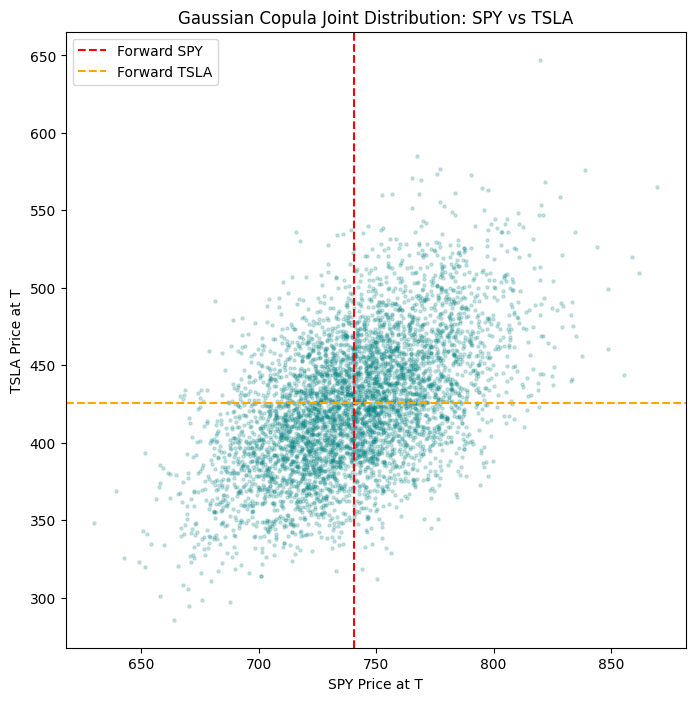

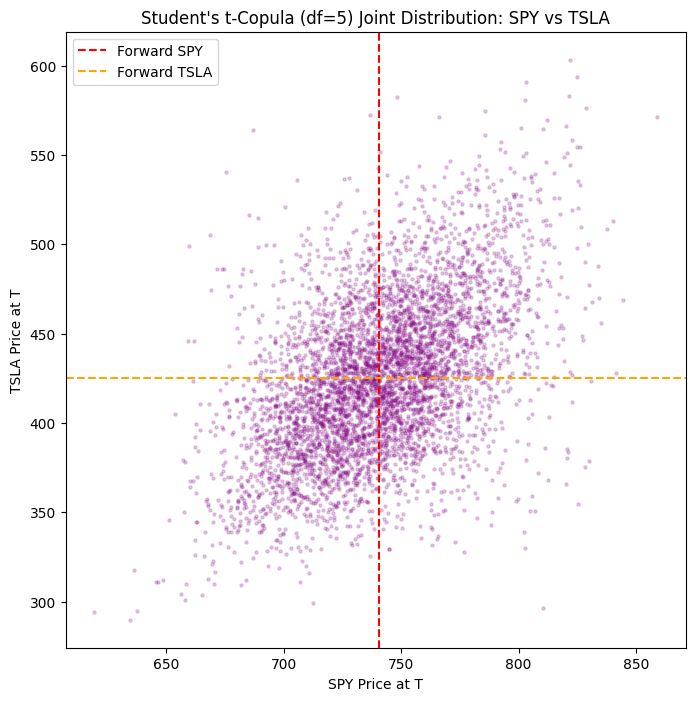

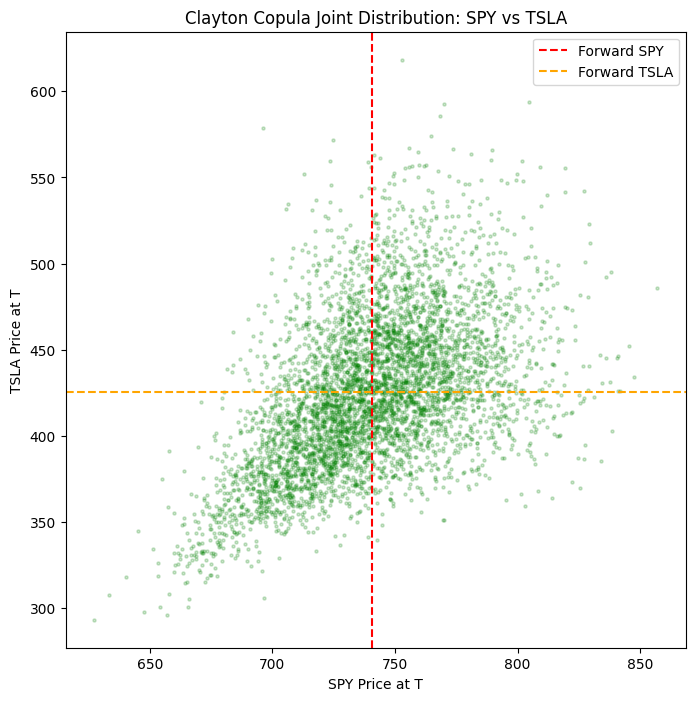

In [12]:
def get_market_correlation(ticker1, ticker2, period="1y"):
    """Fetches data and calculates the correlation of log returns."""
    data = yf.download([ticker1, ticker2], period=period, interval="1d")['Close']
    log_returns = np.log(data / data.shift(1)).dropna()
    corr_matrix = log_returns.corr()
    return corr_matrix.iloc[0, 1]

def generate_joint_samples_gaussian_copula(n_sims, corr, F1, F2, T, p1, p2):
    """
    Generates correlated terminal prices using a Gaussian Copula.
    p1, p2 = (alpha, beta, rho, nu) for each asset
    """
    # Generate Joint Dependency (Gaussian Copula)
    z = multivariate_normal.rvs(mean=[0,0], cov=[[1, corr], [corr, 1]], size=n_sims)
    u, v = norm.cdf(z[:, 0]), norm.cdf(z[:, 1])

    # Use sabr_vol at-the-money to find the simulation vol
    v_sim1 = sabr_vol(F1, F1, T, *p1)
    v_sim2 = sabr_vol(F2, F2, T, *p2)

    # Project Prices
    S1_T = F1 * np.exp((-0.5 * v_sim1**2) * T + v_sim1 * np.sqrt(T) * norm.ppf(u))
    S2_T = F2 * np.exp((-0.5 * v_sim2**2) * T + v_sim2 * np.sqrt(T) * norm.ppf(v))

    return S1_T, S2_T

def generate_joint_samples_t_copula(n_sims, corr, F1, F2, T, p1, p2, df=5):
    """
    Generates correlated terminal prices using a Student's t-Copula.
    p1, p2 = (alpha, beta, rho, nu) for each asset
    df: degrees of freedom for the t-distribution.
    """
    # Generate Correlated t-distributed variables
    cov_t = np.array([[1, corr], [corr, 1]])
    z_norm = multivariate_normal.rvs(mean=[0,0], cov=cov_t, size=n_sims)
    w = np.random.chisquare(df, n_sims) / df
    z_t_corr = z_norm / np.sqrt(w[:, np.newaxis])

    # Convert correlated t-variates to uniform (0,1) marginals using t.cdf
    u = sps_t.cdf(z_t_corr[:, 0], df=df)
    v = sps_t.cdf(z_t_corr[:, 1], df=df)

    # Use sabr_vol at-the-money to find the simulation vol
    v_sim1 = sabr_vol(F1, F1, T, *p1)
    v_sim2 = sabr_vol(F2, F2, T, *p2)

    # Project Prices
    S1_T = F1 * np.exp((-0.5 * v_sim1**2) * T + v_sim1 * np.sqrt(T) * norm.ppf(u))
    S2_T = F2 * np.exp((-0.5 * v_sim2**2) * T + v_sim2 * np.sqrt(T) * norm.ppf(v))

    return S1_T, S2_T

def generate_joint_samples_clayton_copula(n_sims, corr, F1, F2, T, p1, p2):
    """
    Generates correlated terminal prices using a Clayton Copula.
    Clayton copula models lower-tail dependence.
    p1, p2 = (alpha, beta, rho, nu) for each asset
    """
    # Convert Pearson's rho (dynamic_corr) to Kendall's Tau for Gaussian copula and then to Clayton's theta parameter.
    tau = (2 / np.pi) * np.arcsin(corr)

    # For Clayton copula: tau = theta / (theta + 2) => theta = 2*tau / (1 - tau)
    # Ensure tau is less than 1 for a valid theta, and theta > 0
    if tau >= 1.0 or tau <= 0.0: # Clayton requires positive dependence
        print(f"Warning: Cannot use Clayton copula for tau={tau:.4f}. Defaulting theta to 0.1 for weak dependence.")
        theta = 0.1
    else:
        theta = (2 * tau) / (1 - tau)

    # Generate Correlated Uniforms via Clayton Copula
    # Simulation method for Clayton (d=2):
    # Generate W ~ Gamma(1/theta, 1) (shape=1/theta, scale=1)
    # Generate E1, E2 ~ Exponential(1) (i.e. -log(U) for U~U(0,1))
    # u = (1 + E1/W)^(-1/theta), v = (1 + E2/W)^(-1/theta)

    W = np.random.gamma(1/theta, 1, n_sims) # Shape=1/theta, Scale=1
    U1_rand = np.random.uniform(0, 1, n_sims)
    U2_rand = np.random.uniform(0, 1, n_sims)
    E1 = -np.log(U1_rand)
    E2 = -np.log(U2_rand)
    W[W <= 1e-10] = 1e-10 # Set a floor for W to prevent division errors
    u = (1 + E1 / W)**(-1/theta)
    v = (1 + E2 / W)**(-1/theta)

    # Use sabr_vol at-the-money to find the simulation vol
    v_sim1 = sabr_vol(F1, F1, T, *p1)
    v_sim2 = sabr_vol(F2, F2, T, *p2)

    # Project Prices
    S1_T = F1 * np.exp((-0.5 * v_sim1**2) * T + v_sim1 * np.sqrt(T) * norm.ppf(u))
    S2_T = F2 * np.exp((-0.5 * v_sim2**2) * T + v_sim2 * np.sqrt(T) * norm.ppf(v))

    return S1_T, S2_T

ticker_1 = "SPY"
ticker_2 = "TSLA"
exp_idx = 10
n_sim = 50000

# Fetch real-market correlation
dynamic_corr = get_market_correlation(ticker_1, ticker_2)
print(f"Historical Correlation between {ticker_1} and {ticker_2}: {dynamic_corr:.4f}")

# Call existing functions to get Forwards and Calibrated Params
F1, date1 = get_implied_forward(ticker_1, exp_idx)
F2, date2 = get_implied_forward(ticker_2, exp_idx)
K1_option, K2_option = 0.95 * F1, 0.95 * F2 # Strike prices for the worst-of put

# Calibrate Asset 1
S1_data = get_live_sabr_data(ticker_1, exp_idx)
res1 = calibrate_sabr(S1_data[3], S1_data[2], F1, S1_data[1])
params1 = res1.x # alpha1, beta1, rho1, nu1
alph1, beta1, rho1, nu1 = params1

# Calibrate Asset 2
S2_data = get_live_sabr_data(ticker_2, exp_idx)
res2 = calibrate_sabr(S2_data[3], S2_data[2], F2, S2_data[1])
params2 = res2.x # alpha2, beta2, rho2, nu2
alph2, beta2, rho2, nu2 = params2

T_min = min(S1_data[1], S2_data[1]) # Use the smaller T for joint simulation

# === Gaussian Copula Simulation ===
S1_gaussian_samples, S2_gaussian_samples = generate_joint_samples_gaussian_copula(
    n_sim,
    dynamic_corr,
    F1, F2, T_min,
    params1,
    params2
)

# Calculate probability of both assets dropping by 5% or more for Gaussian
crash_count_gaussian = np.sum((S1_gaussian_samples < K1_option) & (S2_gaussian_samples < K2_option))
prob_joint_crash_gaussian = (crash_count_gaussian / n_sim) * 100

# Calculate probability of option payout (either asset drops below strike) for Gaussian
option_payout_count_gaussian = np.sum((S1_gaussian_samples < K1_option) | (S2_gaussian_samples < K2_option))
prob_option_payout_gaussian = (option_payout_count_gaussian / n_sim) * 100

# === Student's t-Copula Simulation ===
df_t_copula = 5 # Degrees of freedom for t-copula (controls tail thickness)
S1_t_samples, S2_t_samples = generate_joint_samples_t_copula(
    n_sim,
    dynamic_corr,
    F1, F2, T_min,
    params1,
    params2,
    df=df_t_copula
)

# Calculate probability of both assets dropping by 5% or more for Student's t
crash_count_t = np.sum((S1_t_samples < K1_option) & (S2_t_samples < K2_option))
prob_joint_crash_t = (crash_count_t / n_sim) * 100

# Calculate probability of option payout (either asset drops below strike) for Student's t
option_payout_count_t = np.sum((S1_t_samples < K1_option) | (S2_t_samples < K2_option))
prob_option_payout_t = (option_payout_count_t / n_sim) * 100

# === Clayton Copula Simulation ===
S1_clayton_samples, S2_clayton_samples = generate_joint_samples_clayton_copula(
    n_sim,
    dynamic_corr,
    F1, F2, T_min,
    params1,
    params2
)

# Calculate probability of both assets dropping by 5% or more for Clayton
crash_count_clayton = np.sum((S1_clayton_samples < K1_option) & (S2_clayton_samples < K2_option))
prob_joint_crash_clayton = (crash_count_clayton / n_sim) * 100

# Calculate probability of option payout (either asset drops below strike) for Clayton
option_payout_count_clayton = np.sum((S1_clayton_samples < K1_option) | (S2_clayton_samples < K2_option))
prob_option_payout_clayton = (option_payout_count_clayton / n_sim) * 100

# === Gaussian Copula Simulation ===
S1_gaussian_samples, S2_gaussian_samples = generate_joint_samples_gaussian_copula(
    n_sim,
    dynamic_corr,
    F1, F2, T_min,
    (alph1, beta1, rho1, nu1),
    (alph2, beta2, rho2, nu2)
)

# Application: Pricing a 'Worst-of' Put Option (Gaussian)
K1_put, K2_put = 0.95 * F1, 0.95 * F2
K1_call, K2_call = 1.05 * F1, 1.05 * F2
worst_of_put_payoffs_gaussian = np.maximum(0, np.maximum(K1_put - S1_gaussian_samples, K2_put - S2_gaussian_samples))
best_of_call_payoffs_gaussian = np.maximum(0, np.maximum(S1_gaussian_samples - K1_call, S2_gaussian_samples - K2_call))
worst_of_option_price_gaussian = np.exp(-r * T_min) * np.mean(worst_of_put_payoffs_gaussian) # using martingale
best_of_option_price_gaussian = np.exp(-r * T_min) * np.mean(best_of_call_payoffs_gaussian) # using martingale

print(f"Joint Expiry Date: {date1}")

# === Student's t-Copula Simulation ===
df_t_copula = 5 # Degrees of freedom for t-copula (controls tail thickness)
S1_t_samples, S2_t_samples = generate_joint_samples_t_copula(
    n_sim,
    dynamic_corr,
    F1, F2, T_min,
    (alph1, beta1, rho1, nu1),
    (alph2, beta2, rho2, nu2),
    df=df_t_copula
)

# Application: Pricing a 'Worst-of' Put Option (Student's t)
worst_of_put_payoffs_t = np.maximum(0, np.maximum(K1_put - S1_t_samples, K2_put - S2_t_samples))
best_of_call_payoffs_t = np.maximum(0, np.maximum(S1_t_samples - K1_call, S2_t_samples - K2_call))
worst_of_put_option_price_t = np.exp(-r * T_min) * np.mean(worst_of_put_payoffs_t) # using martingale
best_of_call_option_price_t = np.exp(-r * T_min) * np.mean(best_of_call_payoffs_t) # using martingale

# === Clayton Copula Simulation ===
S1_clayton_samples, S2_clayton_samples = generate_joint_samples_clayton_copula(
    n_sim,
    dynamic_corr,
    F1, F2, T_min,
    (alph1, beta1, rho1, nu1),
    (alph2, beta2, rho2, nu2)
)

# Application: Pricing a 'Worst-of' Put Option (Clayton)
worst_of_put_payoffs_clayton = np.maximum(0, np.maximum(K1_put - S1_clayton_samples, K2_put - S2_clayton_samples))
best_of_call_payoffs_clayton = np.maximum(0, np.maximum(S1_clayton_samples - K1_call, S2_clayton_samples - K2_call))
worst_of_put_option_price_clayton = np.exp(-r * T_min) * np.mean(worst_of_put_payoffs_clayton) # using martingale
best_of_call_option_price_clayton = np.exp(-r * T_min) * np.mean(best_of_call_payoffs_clayton) # using martingale

metrics_data = {
    'Metric': [
        'Worst-of Put Option Price',
        'Best-of Call Option Price',
        'Prob. of Both Assets Dropping by 5%+ (AND)',
        'Prob. of Worst-of put option payout (OR)'
    ],
    'Gaussian Copula': [
        f'${worst_of_option_price_gaussian:.4f}',
        f'${best_of_option_price_gaussian:.4f}',
        f'{prob_joint_crash_gaussian:.2f}%',
        f'{prob_option_payout_gaussian:.2f}%'
    ],
    "Student's t-Copula (df=5)": [
        f'${worst_of_put_option_price_t:.4f}',
        f'${best_of_call_option_price_t:.4f}',
        f'{prob_joint_crash_t:.2f}%',
        f'{prob_option_payout_t:.2f}%'
    ],
    'Clayton Copula': [
        f'${worst_of_put_option_price_clayton:.4f}',
        f'${best_of_call_option_price_clayton:.4f}',
        f'{prob_joint_crash_clayton:.2f}%',
        f'{prob_option_payout_clayton:.2f}%'
    ]
}

df_comparison_copulas = pd.DataFrame(metrics_data)
display(df_comparison_copulas)
print('\n')
# === Visualization ===

# Gaussian Copula Visualization
plt.figure(figsize=(8, 8))
plt.scatter(S1_gaussian_samples[:5000], S2_gaussian_samples[:5000], alpha=0.2, s=5, color='teal')
plt.axvline(F1, color='red', linestyle='--', label=f'Forward {ticker_1}')
plt.axhline(F2, color='orange', linestyle='--', label=f'Forward {ticker_2}')
plt.title(f"Gaussian Copula Joint Distribution: {ticker_1} vs {ticker_2}")
plt.xlabel(f"{ticker_1} Price at T")
plt.ylabel(f"{ticker_2} Price at T")
plt.legend()
plt.show()
print('\n')

# Student's t-Copula Visualization
plt.figure(figsize=(8, 8))
plt.scatter(S1_t_samples[:5000], S2_t_samples[:5000], alpha=0.2, s=5, color='purple')
plt.axvline(F1, color='red', linestyle='--', label=f'Forward {ticker_1}')
plt.axhline(F2, color='orange', linestyle='--', label=f'Forward {ticker_2}')
plt.title(f"Student's t-Copula (df={df_t_copula}) Joint Distribution: {ticker_1} vs {ticker_2}")
plt.xlabel(f"{ticker_1} Price at T")
plt.ylabel(f"{ticker_2} Price at T")
plt.legend()
plt.show()
print('\n')

# Clayton Copula Visualization (NEWLY ADDED)
plt.figure(figsize=(8, 8))
plt.scatter(S1_clayton_samples[:5000], S2_clayton_samples[:5000], alpha=0.2, s=5, color='green')
plt.axvline(F1, color='red', linestyle='--', label=f'Forward {ticker_1}')
plt.axhline(F2, color='orange', linestyle='--', label=f'Forward {ticker_2}')
plt.title(f"Clayton Copula Joint Distribution: {ticker_1} vs {ticker_2}")
plt.xlabel(f"{ticker_1} Price at T")
plt.ylabel(f"{ticker_2} Price at T")
plt.legend()
plt.show()
print('\n')

## Interpretation of Worst-of Put and Best-of Call Option Prices

The pricing of multi-asset options, such as 'worst-of' puts and 'best-of' calls, is highly sensitive to the chosen dependence structure between the underlying assets. The Monte Carlo simulations using Gaussian, Student's t, and Clayton copulas reveal distinct pricing characteristics due to how each copula models joint extreme events.

### Worst-of Put Option Price Analysis

The Clayton copula increases the probability of both assets falling together, which would increase the likelihood of `(K_1 - S_1)` and `(K_2 - S_2)` being positive, and thus increase the option price. The observed lower price suggests that while it captures lower-tail dependence, the overall distribution of the 'worst' asset's loss (max loss between the two) might be less severe than in the t-Copula, or the specific strikes (95% of forward) are not deep enough in the tails to fully exploit Clayton's lower-tail strength in this particular scenario. It is crucial to examine the joint probability of `(S1 < K1)` OR `(S2 < K2)` (the 'option payout' probability) and the magnitude of losses captured by each copula.

### Best-of Call Option Price Analysis

The Clayton copula exhibits **upper-tail independence**, meaning it assumes little to no dependence in extreme positive events. However, the price for the best-of call is the highest with Clayton. This might seem contradictory. The key is that while Clayton models upper-tail *independence*, its strong lower-tail dependence means that if one asset goes down significantly, the other is more likely to go down too. This indirectly impacts the distribution of the *maximum* of the two assets. If the lower-tail dependence leads to a narrower distribution of values for `min(S1, S2)`, it might spread out the distribution of `max(S1, S2)` in a way that benefits the call option, or it simply reflects a different overall shape of the joint distribution that, by chance, yields a higher expected payoff for this specific best-of call structure when discounted.

### Conclusion

The pricing differences underscore the importance of selecting an appropriate copula model that accurately reflects the dependence structure of the underlying assets. While the Clayton copula is theoretically strong for modeling lower-tail dependence, its impact on option prices for specific strikes and expiries can be complex and may not always lead to the highest prices for 'worst-of' puts or lowest for 'best-of' calls, especially when compared to a Student's t-copula that models both tails simultaneously. The Student's t-copula, with its ability to model overall tail fatness, often provides a more robust estimate for options sensitive to extreme events in both directions.

### Visualization of Joint Distribution

The scatter plots display the simulated terminal prices for SPY (x-axis) and TSLA (y-axis) for all three copula models.

-   **Gaussian Copula Plot (teal)**: Shows a relatively elliptical cloud of points, reflecting the normal assumption of joint movements. While it captures the overall positive correlation, the density of points in the extreme corners (tails) is lower.
-   **Student's t-Copula Plot (purple)**: Also shows a positive correlation, but with a visibly higher density of points in the tails. This means more simulated scenarios resulted in both assets experiencing large gains or large losses together, which is characteristic of tail dependence.
-   **Clayton Copula Plot (green)**: Displays a pronounced clustering of points in the lower-left tail, indicating a strong correlation when both assets experience significant negative returns. The upper tail shows less dependence, which is a key characteristic of the Clayton copula.

### Overall Interpretation

The analysis successfully demonstrates how different copula models can capture varying aspects of asset dependence, particularly in extreme market conditions. The **Clayton Copula provides the most conservative (and often most realistic for financial markets) estimate** for derivatives sensitive to joint tail events, leading to the highest option price in this 'worst-of' scenario. This highlights the importance of choosing an appropriate dependence model for accurate risk assessment and pricing in multi-asset portfolios.

Further scope for improvement
-
- Visualize volatility smiles from all expriries and use the better looking expiries to optimize the parameters (use a smaller sample from the sorted data if required).
- Analyze the comparison of Greeks from SABR and BS model.